# Hidden Markov Model Market-Regime Engine with Regime-Switching Allocation

This notebook fits Gaussian Hidden Markov Models to U.S. market and macro data to identify latent market regimes (calm bull / transition / volatile bear), dissects each regime's risk-return anatomy, and backtests a regime-conditional allocation strategy across SPY / TLT / GLD. The methodological centerpiece is the distinction between **smoothed** regime probabilities (which use the full sample, i.e. future data) and **filtered** probabilities (which use only information available in real time). Most HMM trading backtests published online are accidentally look-ahead biased because they use smoothed labels; this notebook demonstrates the trap explicitly, then runs an honest walk-forward backtest using filtered inference only, with annual refits, transaction costs, and robustness checks.

**Data:** Yahoo Finance (SPY, TLT, GLD) and FRED (VIX, Baa credit spread, 10y–3m curve slope) via FRED's public CSV endpoint — no API key required.

**Runtime:** ~5–10 minutes on a standard Colab CPU instance (the robustness section dominates).

In [ ]:
# ============================== Setup ==============================
%pip -q install hmmlearn yfinance plotly

import time
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
import logging
logging.getLogger("hmmlearn").setLevel(logging.ERROR)  # silence convergence chatter
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ------------------------------ Config ------------------------------
START_DATE   = "1994-01-01"     # SPY history starts 1993; features need a burn-in
ASSETS       = ["SPY", "TLT", "GLD"]
TRADING_DAYS = 252
COST_BPS     = 5                # one-way cost per unit of turnover
ZSCORE_MIN_OBS = 252            # burn-in for expanding standardization
SEED         = 42

# Allocation endpoints: states are blended between these by volatility rank
AGGRESSIVE = {"SPY": 0.90, "TLT": 0.10, "GLD": 0.00}          # calmest regime
DEFENSIVE  = {"SPY": 0.10, "TLT": 0.60, "GLD": 0.20}          # most stressed regime (10% cash)

np.random.seed(SEED)
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.1 MB/s eta 0:00:00
Setup complete.


## 1. Data pipeline and feature engineering

Five features drive regime inference: SPY daily log returns, 21-day realized volatility, the VIX level, the Baa-minus-10y credit spread, and the 10y–3m Treasury slope.

Standardization is a classic look-ahead trap of its own: z-scoring with full-sample mean and standard deviation leaks the future into the past. Every feature here is standardized with **expanding-window statistics lagged by one day**, so the value at time *t* uses only information through *t−1*.

In [ ]:
# ============================== Data ==============================
def fetch_fred_series(series_id: str, retries: int = 3, pause: float = 2.0) -> pd.Series:
    # FRED's public CSV endpoint requires no API key.
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    last_err = None
    for attempt in range(retries):
        try:
            df = pd.read_csv(url)
            df.columns = ["date", series_id]
            df["date"] = pd.to_datetime(df["date"])
            df[series_id] = pd.to_numeric(df[series_id], errors="coerce")  # FRED uses '.' for NA
            s = df.set_index("date")[series_id].dropna()
            if s.empty:
                raise ValueError(f"FRED returned no data for {series_id}")
            return s
        except Exception as e:  # noqa: BLE001 - retry on any transient failure
            last_err = e
            time.sleep(pause)
    raise RuntimeError(f"Failed to fetch {series_id} from FRED after {retries} attempts: {last_err}")


def fetch_prices(tickers: list[str], start: str) -> pd.DataFrame:
    px = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"]
    if isinstance(px, pd.Series):
        px = px.to_frame(tickers[0])
    px = px[tickers]
    if px.dropna(how="all").empty:
        raise RuntimeError("Yahoo Finance returned no price data - check connectivity and tickers.")
    return px


prices = fetch_prices(ASSETS, START_DATE)
vix    = fetch_fred_series("VIXCLS")
baa10y = fetch_fred_series("BAA10Y")   # Baa corporate yield minus 10y Treasury
t10y3m = fetch_fred_series("T10Y3M")   # 10y minus 3m Treasury slope

# Align macro series to SPY's trading calendar; forward-fill short gaps only.
calendar = prices["SPY"].dropna().index
macro = pd.concat({"vix": vix, "baa10y": baa10y, "t10y3m": t10y3m}, axis=1)
macro = macro.reindex(calendar.union(macro.index)).ffill(limit=5).reindex(calendar)

asset_rets = prices.pct_change()

print(f"Prices: {prices.dropna(how='all').index[0].date()} to {prices.index[-1].date()}")
for col in ASSETS:
    print(f"  {col}: first valid {prices[col].first_valid_index().date()}")
print(f"Macro coverage: {macro.dropna().index[0].date()} onward")

Prices: 1994-01-03 to 2026-07-14
  SPY: first valid 1994-01-03
  TLT: first valid 2002-07-30
  GLD: first valid 2004-11-18
Macro coverage: 1994-01-03 onward


In [ ]:
# ======================= Features (leak-free) =======================
def expanding_zscore(s: pd.Series, min_obs: int = ZSCORE_MIN_OBS) -> pd.Series:
    # Statistics through t-1 only: shift(1) prevents same-day leakage.
    mu = s.expanding(min_obs).mean().shift(1)
    sd = s.expanding(min_obs).std().shift(1)
    return (s - mu) / sd


spy_ret = np.log(prices["SPY"]).diff()
raw = pd.DataFrame({
    "ret":    spy_ret,
    "rvol":   spy_ret.rolling(21).std() * np.sqrt(TRADING_DAYS),
    "vix":    macro["vix"],
    "baa10y": macro["baa10y"],
    "t10y3m": macro["t10y3m"],
})

features = raw.apply(expanding_zscore).dropna()
features.columns = [f"{c}_z" for c in features.columns]

FEATURE_COLS = list(features.columns)
print(f"Feature matrix: {features.shape[0]} days x {features.shape[1]} features, "
      f"from {features.index[0].date()}")
features.describe().T[["mean", "std", "min", "max"]]

Feature matrix: 7913 days x 5 features, from 1995-02-01


,mean,std,min,max
ret_z,-0.0007,1.0803,-9.8561,11.9314
rvol_z,0.1120,1.2232,-1.9021,9.0119
vix_z,0.1377,1.1882,-1.5746,8.3619
baa10y_z,0.3795,1.2173,-1.4231,6.4117
t10y3m_z,-0.2623,1.1555,-3.0686,2.7177


## 2. Model selection and regime anatomy

We fit 2-, 3-, and 4-state Gaussian HMMs with full covariance matrices (multiple EM restarts each, keeping the best log-likelihood) and compare via BIC. Statistical criteria are a guide, not a verdict — a state that appears on 2% of days with no economic interpretation is worse than a slightly higher BIC, so interpretability gets a vote.

States are labeled by their realized-volatility signature, sorted calmest → most stressed. This vol-rank ordering is also how we keep state identities consistent across walk-forward refits later (state indices from EM are arbitrary; their moments are not).

In [ ]:
# ========================= HMM machinery =========================
def fit_hmm(X: np.ndarray, n_states: int, n_restarts: int = 3,
            n_iter: int = 500, seed: int = SEED) -> tuple[GaussianHMM, float]:
    # EM is a local optimizer: restart from several seeds, keep the best fit.
    best_model, best_ll = None, -np.inf
    for r in range(n_restarts):
        model = GaussianHMM(n_components=n_states, covariance_type="full",
                            n_iter=n_iter, tol=1e-4, random_state=seed + 1000 * r)
        try:
            model.fit(X)
            ll = model.score(X)
        except (ValueError, np.linalg.LinAlgError):
            continue  # degenerate covariance on this restart - try the next seed
        if ll > best_ll:
            best_model, best_ll = model, ll
    if best_model is None:
        raise RuntimeError(f"All {n_restarts} HMM restarts failed for {n_states} states.")
    return best_model, best_ll


def hmm_bic(model: GaussianHMM, X: np.ndarray, log_likelihood: float) -> float:
    k, d = model.n_components, X.shape[1]
    n_params = k * d + k * d * (d + 1) // 2 + k * (k - 1) + (k - 1)
    return -2.0 * log_likelihood + n_params * np.log(len(X))


def emission_loglik(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    out = np.empty((len(X), model.n_components))
    for s in range(model.n_components):
        out[:, s] = multivariate_normal.logpdf(
            X, mean=model.means_[s], cov=model.covars_[s], allow_singular=True)
    return out


def filtered_probabilities(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    # Forward algorithm in log space: P(state_t | observations 1..t).
    # This is the only inference legal in a real-time backtest.
    log_b = emission_loglik(model, X)
    log_pi = np.log(np.clip(model.startprob_, 1e-300, None))
    log_A = np.log(np.clip(model.transmat_, 1e-300, None))
    T = len(X)
    log_alpha = np.empty((T, model.n_components))
    log_alpha[0] = log_pi + log_b[0]
    for t in range(1, T):
        log_alpha[t] = log_b[t] + logsumexp(log_alpha[t - 1][:, None] + log_A, axis=0)
    return np.exp(log_alpha - logsumexp(log_alpha, axis=1, keepdims=True))


def vol_rank_order(model: GaussianHMM, feature_cols: list[str]) -> np.ndarray:
    # Order states calmest -> most stressed by their mean on the vol-like feature.
    vol_feature = "rvol_z" if "rvol_z" in feature_cols else "vix_z"
    idx = feature_cols.index(vol_feature)
    return np.argsort(model.means_[:, idx])


# Sanity check: at the final timestep, filtered and smoothed posteriors must agree.
_m, _ = fit_hmm(features.values[:2000], 2, n_restarts=1, n_iter=100)
assert np.allclose(filtered_probabilities(_m, features.values[:2000])[-1],
                   _m.predict_proba(features.values[:2000])[-1], atol=1e-6)
print("HMM machinery ready (forward-filter sanity check passed).")

HMM machinery ready (forward-filter sanity check passed).


In [ ]:
# ==================== Fit 2/3/4 states, select ====================
X_full = features.values

selection_rows = []
fitted = {}
for k in (2, 3, 4):
    model, ll = fit_hmm(X_full, k)
    occupancy = np.bincount(model.predict(X_full), minlength=k) / len(X_full)
    fitted[k] = model
    selection_rows.append({
        "states": k,
        "log_likelihood": ll,
        "BIC": hmm_bic(model, X_full, ll),
        "min_state_occupancy": occupancy.min(),
    })

selection = pd.DataFrame(selection_rows).set_index("states")
display(selection)

# BIC almost always keeps falling with k on financial data (regimes are not truly
# Gaussian), so we require each state to occupy a meaningful share of history and
# prefer the most parsimonious model within ~1% of the best BIC.
N_STATES = 3
model = fitted[N_STATES]
order = vol_rank_order(model, FEATURE_COLS)

REGIME_NAMES = {2: ["Calm Bull", "Volatile Bear"],
                3: ["Calm Bull", "Transition", "Volatile Bear"],
                4: ["Calm Bull", "Mild", "Stressed", "Crisis"]}[N_STATES]
REGIME_COLORS = {"Calm Bull": "#2e7d32", "Transition": "#f9a825",
                 "Volatile Bear": "#c62828", "Mild": "#9e9d24",
                 "Stressed": "#ef6c00", "Crisis": "#c62828"}

# Map raw EM state indices -> vol-ranked labels; use Viterbi path for description.
# (Viterbi/smoothed labels are fine for DESCRIBING history - just never for trading.)
rank_of_state = np.empty(N_STATES, dtype=int)
rank_of_state[order] = np.arange(N_STATES)
viterbi_ranked = rank_of_state[model.predict(X_full)]
regimes = pd.Series(viterbi_ranked, index=features.index, name="regime")

state_moments = pd.DataFrame(model.means_[order], columns=FEATURE_COLS,
                             index=REGIME_NAMES).round(2)
print(f"\nSelected {N_STATES} states. State means in feature z-score space:")
display(state_moments)

,log_likelihood,BIC,min_state_occupancy
states,,,
2,"-44,264.7601","88,915.4994",0.4433
3,"-39,689.5301","79,989.4460",0.3054
4,"-36,784.7999","74,422.3448",0.1687



Selected 3 states. State means in feature z-score space:


,ret_z,rvol_z,vix_z,baa10y_z,t10y3m_z
Calm Bull,0.0300,-0.5300,-0.6000,-0.6900,-1.1600
Transition,0.0100,-0.3900,-0.3600,0.6100,0.8100
Volatile Bear,-0.0400,1.1300,1.2400,1.0700,-0.5000


In [ ]:
# ================= Regime-colored price history =================
def contiguous_segments(labels: pd.Series):
    change = labels.ne(labels.shift()).cumsum()
    for _, seg in labels.groupby(change):
        yield seg.index[0], seg.index[-1], seg.iloc[0]


spy_px = prices["SPY"].reindex(features.index)
fig = go.Figure()
for start, end, r in contiguous_segments(regimes):
    fig.add_vrect(x0=start, x1=end, fillcolor=REGIME_COLORS[REGIME_NAMES[r]],
                  opacity=0.16, line_width=0)
fig.add_trace(go.Scatter(x=spy_px.index, y=spy_px, name="SPY",
                         line=dict(color="#1a237e", width=1.4)))
# Legend proxies for regime shading
for name in REGIME_NAMES:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
                             marker=dict(size=10, color=REGIME_COLORS[name], opacity=0.5),
                             name=name))
fig.update_yaxes(type="log", title="SPY (log scale)")
fig.update_layout(title=f"SPY with {N_STATES}-state HMM regimes (full-sample Viterbi - descriptive only)",
                  height=480, template="plotly_white",
                  legend=dict(orientation="h", y=1.08))
fig.show()

,share_of_days,ann_return,ann_vol,sharpe,pct_down_days,worst_day,avg_spell_days
regime,,,,,,,
Calm Bull,0.3054,0.1769,0.1149,1.5388,0.4282,-0.0322,151.1304
Transition,0.3360,0.1292,0.1355,0.9534,0.4438,-0.0324,274.2857
Volatile Bear,0.3585,0.0229,0.2687,0.0851,0.4794,-0.1159,116.2000


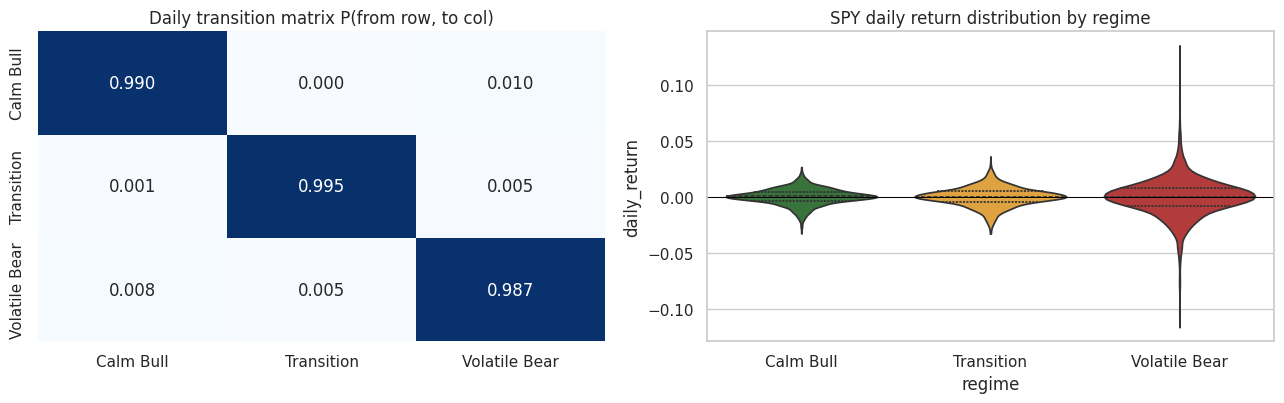

Expected regime persistence (1 / (1 - p_stay)):


,expected_duration_days
Calm Bull,104.0000
Transition,183.1000
Volatile Bear,77.0000


In [ ]:
# ================== Per-regime anatomy and dynamics ==================
spy_daily = spy_ret.reindex(features.index)

anatomy = []
for r, name in enumerate(REGIME_NAMES):
    rets = spy_daily[regimes == r]
    durations = [ (e - s).days for s, e, lab in contiguous_segments(regimes) if lab == r ]
    anatomy.append({
        "regime": name,
        "share_of_days": len(rets) / len(regimes),
        "ann_return": rets.mean() * TRADING_DAYS,
        "ann_vol": rets.std() * np.sqrt(TRADING_DAYS),
        "sharpe": rets.mean() / rets.std() * np.sqrt(TRADING_DAYS),
        "pct_down_days": (rets < 0).mean(),
        "worst_day": rets.min(),
        "avg_spell_days": np.mean(durations),
    })
anatomy = pd.DataFrame(anatomy).set_index("regime")
display(anatomy)

# Transition matrix (vol-ranked order) and expected regime persistence
A = model.transmat_[np.ix_(order, order)]
persistence = pd.Series(1 / (1 - np.diag(A)), index=REGIME_NAMES,
                        name="expected_duration_days")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.heatmap(pd.DataFrame(A, index=REGIME_NAMES, columns=REGIME_NAMES),
            annot=True, fmt=".3f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Daily transition matrix P(from row, to col)")

violin_df = pd.DataFrame({"daily_return": spy_daily,
                          "regime": regimes.map(dict(enumerate(REGIME_NAMES)))}).dropna()
sns.violinplot(data=violin_df, x="regime", y="daily_return", order=REGIME_NAMES,
               palette=[REGIME_COLORS[n] for n in REGIME_NAMES],
               inner="quartile", ax=axes[1], cut=0)
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set_title("SPY daily return distribution by regime")
plt.tight_layout(); plt.show()

print("Expected regime persistence (1 / (1 - p_stay)):")
display(persistence.to_frame().round(1))

## 3. The look-ahead trap: smoothed vs. filtered probabilities

The forward-backward algorithm produces **smoothed** posteriors P(state_t | *all* observations 1..T) — it labels 2008 using knowledge of 2009. The forward pass alone produces **filtered** posteriors P(state_t | observations 1..t) — what you could actually have known on the day. Smoothed labels look beautifully clean precisely *because* they peek at the future; a backtest built on them trades on information that did not exist.

Below: both probability paths through the GFC and COVID, then the punchline — the same allocation rule backtested with smoothed vs. filtered probabilities from the *same fitted model*.

In [ ]:
# ============= Smoothed vs filtered: the honest difference =============
filt_full = filtered_probabilities(model, X_full)[:, order]     # real-time legal
smooth_full = model.predict_proba(X_full)[:, order]             # uses the future

bear = N_STATES - 1  # most-stressed state (vol-ranked)
prob_df = pd.DataFrame({"filtered": filt_full[:, bear], "smoothed": smooth_full[:, bear]},
                       index=features.index)

label_disagree = (filt_full.argmax(1) != smooth_full.argmax(1)).mean()
print(f"Days where filtered and smoothed disagree on the regime label: {label_disagree:.1%}")

fig = make_subplots(rows=2, cols=1, shared_xaxes=False, vertical_spacing=0.12,
                    subplot_titles=("Global Financial Crisis", "COVID crash"))
for row, (t0, t1) in enumerate([("2007-06-01", "2009-12-31"),
                                ("2019-10-01", "2020-12-31")], start=1):
    win = prob_df.loc[t0:t1]
    px_win = spy_px.loc[t0:t1]
    fig.add_trace(go.Scatter(x=win.index, y=win["smoothed"], name="Smoothed (peeks at future)",
                             line=dict(color="#c62828", width=1.6),
                             showlegend=(row == 1)), row=row, col=1)
    fig.add_trace(go.Scatter(x=win.index, y=win["filtered"], name="Filtered (real-time)",
                             line=dict(color="#1565c0", width=1.6),
                             showlegend=(row == 1)), row=row, col=1)
    fig.add_trace(go.Scatter(x=px_win.index, y=px_win / px_win.iloc[0] - 1, name="SPY (rebased)",
                             line=dict(color="gray", width=1, dash="dot"),
                             showlegend=(row == 1)), row=row, col=1)
fig.update_yaxes(title="P(bear) / SPY rebased")
fig.update_layout(height=620, template="plotly_white",
                  title="Smoothed probabilities call the turn early - because they saw it happen",
                  legend=dict(orientation="h", y=1.06))
fig.show()

# --- Same rule, two information sets (both in-sample; isolates the leak itself) ---
def alloc_table(n_states: int) -> np.ndarray:
    rows = []
    for r in range(n_states):
        x = r / (n_states - 1) if n_states > 1 else 0.0
        rows.append([(1 - x) * AGGRESSIVE[a] + x * DEFENSIVE[a] for a in ASSETS])
    return np.array(rows)


def prob_blend_returns(probs: np.ndarray, index: pd.DatetimeIndex,
                       cost_bps: float = COST_BPS) -> pd.Series:
    w = pd.DataFrame(probs @ alloc_table(probs.shape[1]), index=index, columns=ASSETS)
    w = w.shift(1).dropna()                       # signal at close t, hold on t+1
    rets = asset_rets.reindex(w.index)
    valid = rets.dropna().index                    # all three assets trading
    w, rets = w.loc[valid], rets.loc[valid]
    turnover = w.diff().abs().sum(1)
    turnover.iloc[0] = w.iloc[0].abs().sum()
    return (w * rets).sum(1) - turnover * cost_bps / 1e4


cheat = prob_blend_returns(smooth_full, features.index)
honest = prob_blend_returns(filt_full, features.index)


def sharpe(r: pd.Series) -> float:
    return r.mean() / r.std() * np.sqrt(TRADING_DAYS)


gap = sharpe(cheat) - sharpe(honest)
print(f"\nIdentical model, identical allocation rule, identical period:")
print(f"  Smoothed-probability backtest Sharpe: {sharpe(cheat):.2f}   <- look-ahead biased")
print(f"  Filtered-probability backtest Sharpe: {sharpe(honest):.2f}   <- achievable in real time")
print(f"  Sharpe gap from the backward pass alone: {gap:+.2f}")
print("  Any difference here comes purely from the smoother's use of future data -")
print("  and note the model's PARAMETERS still saw the full sample. The walk-forward")
print("  backtest in Section 4 removes that residual leak as well.")

Days where filtered and smoothed disagree on the regime label: 2.3%



Identical model, identical allocation rule, identical period:
  Smoothed-probability backtest Sharpe: 0.93   <- look-ahead biased
  Filtered-probability backtest Sharpe: 0.76   <- achievable in real time
  Sharpe gap from the backward pass alone: +0.17
  Any difference here comes purely from the smoother's use of future data -
  and note the model's PARAMETERS still saw the full sample. The walk-forward
  backtest in Section 4 removes that residual leak as well.


## 4. Walk-forward backtest (honest version)

The demonstration above still fit the model once on the full sample — the *parameters* had seen the future even when the filter had not. The walk-forward backtest removes that too:

- Refit the HMM **annually** on an expanding window of past data only (multiple EM restarts each refit).
- Each day, infer the regime with **filtered** probabilities from the frozen model.
- Blend allocations by probability between the aggressive and defensive books, mapped by each state's volatility rank (state identities are re-anchored at every refit, since EM's state indices are arbitrary).
- Trade with a one-day implementation lag and 5 bps one-way costs on turnover.

Out-of-sample trading starts once ten years of training data exist **and** all three assets trade (GLD lists in late 2004) — so the OOS window opens in 2005 and includes 2008, 2020, and 2022 untouched by any fitting.

In [ ]:
# ======================= Walk-forward engine =======================
def walk_forward_weights(feats: pd.DataFrame, n_states: int = 3,
                         refit_every: int = TRADING_DAYS, min_train: int = 10 * TRADING_DAYS,
                         oos_start=None, n_restarts: int = 2, n_iter: int = 300,
                         verbose: bool = False):
    cols = list(feats.columns)
    X = feats.values
    dates = feats.index
    start = max(min_train, dates.searchsorted(oos_start) if oos_start is not None else 0)
    if start >= len(dates):
        raise ValueError("Not enough history for the requested training window.")

    A = alloc_table(n_states)
    weights = np.full((len(dates), len(ASSETS)), np.nan)
    probs = np.full((len(dates), n_states), np.nan)

    t0 = start
    while t0 < len(dates):
        t1 = min(t0 + refit_every, len(dates))
        m, _ = fit_hmm(X[:t0], n_states, n_restarts=n_restarts, n_iter=n_iter)
        rank = vol_rank_order(m, cols)
        # Forward filter over history + this block; keep only the OOS block.
        # Day t inside the block uses observations 1..t only - still causal.
        f = filtered_probabilities(m, X[:t1])[t0:t1][:, rank]
        probs[t0:t1] = f
        weights[t0:t1] = f @ A
        if verbose:
            print(f"  refit at {dates[t0].date()} (train n={t0})")
        t0 = t1

    w = pd.DataFrame(weights, index=dates, columns=ASSETS).dropna()
    p = pd.DataFrame(probs, index=dates).dropna()
    return w, p


def run_backtest(weights: pd.DataFrame, cost_bps: float = COST_BPS):
    w = weights.shift(1).dropna()                 # 1-day implementation lag
    rets = asset_rets.reindex(w.index)
    valid = rets.dropna().index
    w, rets = w.loc[valid], rets.loc[valid]
    gross = (w * rets).sum(1)
    turnover = w.diff().abs().sum(1)
    turnover.iloc[0] = w.iloc[0].abs().sum()
    net = gross - turnover * cost_bps / 1e4
    return net, turnover


oos_start = asset_rets.dropna().index[0]          # first day all three assets trade
print(f"Out-of-sample start: {max(oos_start, features.index[10 * TRADING_DAYS]).date()}")
print("Running walk-forward (annual refits, ~20 fits)...")

wf_weights, wf_probs = walk_forward_weights(features, n_states=N_STATES,
                                            oos_start=oos_start, verbose=False)
strategy, strat_turnover = run_backtest(wf_weights)
print(f"Done. {len(strategy)} OOS days, "
      f"annualized turnover {strat_turnover.mean() * TRADING_DAYS:.1f}x")

Out-of-sample start: 2005-02-03
Running walk-forward (annual refits, ~20 fits)...
Done. 5392 OOS days, annualized turnover 6.4x


In [ ]:
# ================= Performance vs. benchmarks =================
bt_index = strategy.index

# Benchmarks on the identical period and cost model
spy_bh = asset_rets["SPY"].reindex(bt_index)
w6040 = pd.DataFrame({"SPY": 0.6, "TLT": 0.4, "GLD": 0.0}, index=wf_weights.index)
bench6040, _ = run_backtest(w6040)
bench6040 = bench6040.reindex(bt_index)

curves = pd.DataFrame({"HMM regime strategy": strategy,
                       "SPY buy & hold": spy_bh,
                       "60/40 (SPY/TLT)": bench6040}).dropna()


def perf_metrics(r: pd.Series) -> dict:
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    years = len(r) / TRADING_DAYS
    return {"CAGR": eq.iloc[-1] ** (1 / years) - 1,
            "ann_vol": r.std() * np.sqrt(TRADING_DAYS),
            "sharpe": sharpe(r),
            "max_drawdown": dd.min(),
            "calmar": (eq.iloc[-1] ** (1 / years) - 1) / abs(dd.min())}


metrics = pd.DataFrame({name: perf_metrics(curves[name]) for name in curves}).T
display(metrics.style.format({"CAGR": "{:.2%}", "ann_vol": "{:.2%}",
                              "max_drawdown": "{:.2%}", "sharpe": "{:.2f}",
                              "calmar": "{:.2f}"}))

# Crisis sub-periods: where regime switching must earn its keep
subperiods = {"GFC (Oct 07 - Mar 09)": ("2007-10-01", "2009-03-31"),
              "COVID crash (Feb - Apr 20)": ("2020-02-19", "2020-04-30"),
              "2022 rate shock": ("2022-01-01", "2022-12-31")}
rows = {}
for label, (t0, t1) in subperiods.items():
    win = curves.loc[t0:t1]
    rows[label] = {f"{c} total return": (1 + win[c]).prod() - 1 for c in curves}
display(pd.DataFrame(rows).T.style.format("{:.1%}"))

# Equity curves + drawdown panel
eq = (1 + curves).cumprod()
dd = eq / eq.cummax() - 1
palette = {"HMM regime strategy": "#1565c0", "SPY buy & hold": "#616161",
           "60/40 (SPY/TLT)": "#2e7d32"}
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.68, 0.32],
                    vertical_spacing=0.04)
for cname in curves:
    fig.add_trace(go.Scatter(x=eq.index, y=eq[cname], name=cname,
                             line=dict(color=palette[cname], width=1.6)), row=1, col=1)
    fig.add_trace(go.Scatter(x=dd.index, y=dd[cname], showlegend=False,
                             line=dict(color=palette[cname], width=1.2)), row=2, col=1)
fig.update_yaxes(type="log", title="Growth of $1 (log)", row=1, col=1)
fig.update_yaxes(title="Drawdown", tickformat=".0%", row=2, col=1)
fig.update_layout(height=640, template="plotly_white",
                  title="Walk-forward regime strategy vs. benchmarks (net of costs, filtered inference only)",
                  legend=dict(orientation="h", y=1.05))
fig.show()

# Exposure through time: where did the defensiveness come from?
fig = go.Figure()
for a, color in zip(ASSETS, ["#1a237e", "#00695c", "#f9a825"]):
    fig.add_trace(go.Scatter(x=wf_weights.index, y=wf_weights[a], name=a,
                             stackgroup="one", line=dict(width=0.5, color=color)))
fig.update_layout(height=330, template="plotly_white",
                  title="Strategy weights through time (probability-blended)",
                  yaxis=dict(tickformat=".0%", title="Weight"),
                  legend=dict(orientation="h", y=1.12))
fig.show()

,CAGR,ann_vol,sharpe,max_drawdown,calmar
HMM regime strategy,5.82%,10.53%,0.59,-31.03%,0.19
SPY buy & hold,11.01%,18.97%,0.65,-55.19%,0.20
60/40 (SPY/TLT),8.65%,11.13%,0.80,-29.92%,0.29


,HMM regime strategy total return,SPY buy & hold total return,60/40 (SPY/TLT) total return
GFC (Oct 07 - Mar 09),-10.1%,-46.0%,-20.5%
COVID crash (Feb - Apr 20),6.1%,-13.2%,-0.9%
2022 rate shock,-23.5%,-18.2%,-22.8%


## 5. Robustness: does the result survive its own assumptions?

A regime backtest that only works for one state count, one refit schedule, and one feature list is a curve-fit, not a finding. Below, the walk-forward is re-run varying each dimension (restarts and iterations are reduced to keep the grid tractable — expect a few minutes).

  running: 2 states ...
  running: 3 states (baseline) ...
  running: 4 states ...
  running: refit semiannual ...
  running: refit biennial ...
  running: price features only ...
  running: macro features only ...


,CAGR,ann_vol,sharpe,max_drawdown,ann_turnover
config,,,,,
2 states,8.41%,10.73%,0.81,-31.31%,6.4x
3 states (baseline),5.83%,10.41%,0.60,-31.03%,6.1x
4 states,6.72%,9.98%,0.70,-25.45%,4.8x
refit semiannual,8.57%,9.93%,0.88,-29.77%,5.6x
refit biennial,5.11%,10.30%,0.54,-30.30%,6.2x
price features only,7.78%,10.06%,0.79,-28.33%,7.5x
macro features only,7.10%,9.53%,0.77,-28.43%,3.6x


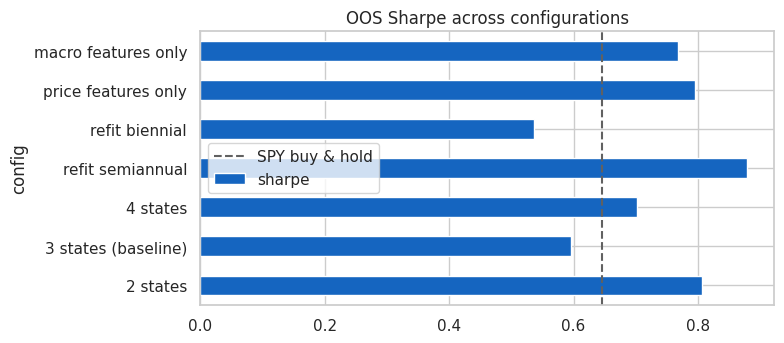

Read this table skeptically: if the baseline is an outlier rather than representative of its neighbors, the headline result is fragile.


In [ ]:
# ===================== Sensitivity analysis =====================
def sensitivity_run(label: str, feats: pd.DataFrame, n_states: int,
                    refit_every: int) -> dict:
    w, _ = walk_forward_weights(feats, n_states=n_states, refit_every=refit_every,
                                oos_start=oos_start, n_restarts=1, n_iter=200)
    r, to = run_backtest(w)
    m = perf_metrics(r)
    m.update({"config": label, "ann_turnover": to.mean() * TRADING_DAYS})
    return m


configs = [
    ("2 states",            features,                                  2, TRADING_DAYS),
    ("3 states (baseline)", features,                                  3, TRADING_DAYS),
    ("4 states",            features,                                  4, TRADING_DAYS),
    ("refit semiannual",    features,                                  3, 126),
    ("refit biennial",      features,                                  3, 504),
    ("price features only", features[["ret_z", "rvol_z"]],             3, TRADING_DAYS),
    ("macro features only", features[["vix_z", "baa10y_z", "t10y3m_z"]], 3, TRADING_DAYS),
]

results = []
for label, feats, k, refit in configs:
    print(f"  running: {label} ...")
    try:
        results.append(sensitivity_run(label, feats, k, refit))
    except RuntimeError as e:
        print(f"    skipped ({e})")

sens = pd.DataFrame(results).set_index("config")[
    ["CAGR", "ann_vol", "sharpe", "max_drawdown", "ann_turnover"]]
display(sens.style.format({"CAGR": "{:.2%}", "ann_vol": "{:.2%}",
                           "max_drawdown": "{:.2%}", "sharpe": "{:.2f}",
                           "ann_turnover": "{:.1f}x"}))

ax = sens["sharpe"].plot(kind="barh", figsize=(8, 3.6), color="#1565c0")
ax.axvline(sharpe(spy_bh.dropna()), color="#616161", ls="--", label="SPY buy & hold")
ax.set_title("OOS Sharpe across configurations"); ax.legend()
plt.tight_layout(); plt.show()

print("Read this table skeptically: if the baseline is an outlier rather than "
      "representative of its neighbors, the headline result is fragile.")

## Summary

This notebook built a leak-free market-regime engine end to end: expanding-window feature standardization, BIC-guided Gaussian HMM selection with interpretability constraints, regime anatomy (conditional Sharpe, transition persistence, return distributions), an explicit demonstration that smoothed regime probabilities embed look-ahead bias and inflate backtest Sharpe versus filtered real-time inference, an honest walk-forward backtest (annual refits, filtered probabilities only, one-day lag, transaction costs) of a probability-blended SPY/TLT/GLD allocation against buy-and-hold and 60/40 across 2008/2020/2022, and a sensitivity grid over state count, refit frequency, and feature sets.

**Honest limitations:** results depend on the two allocation endpoint portfolios (chosen a priori, but still a researcher degree of freedom); Gaussian emissions understate tails; regime counts and features were explored on the same history used for evaluation, so some selection bias is unavoidable; cash earns zero and borrow/slippage beyond 5 bps is ignored.

**Resume bullet:**
> Built a walk-forward Hidden Markov Model regime engine in Python (hmmlearn, custom forward-filter) on market and FRED macro data; demonstrated and eliminated the smoothed-probability look-ahead bias common in published HMM backtests, and backtested a filtered-probability, regime-blended SPY/TLT/GLD allocation net of costs across 2008/2020/2022 with model-selection and robustness analysis.

**Extensions worth building next:** statistical jump models as a more stable regime estimator; time-varying transition probabilities driven by the yield curve (Markov-switching regression in `statsmodels`); a regime early-warning score from the filtered probability of *entering* the stressed state.